## Portfolio 2 - Text classification benchmarks - src1, logistic regression

*By Sofie Mosegaard, 07-03-2024*

In this assignment, I will train a simple (binary) classification model on text data using ```scikit-learn```. The assignment will consist of *two different scripts*. In the first script, I will train a logistic regression classifier. In the second script, I will train a neural network. 

This is the **first script** and will therefore contain code, that trains a logistic regression classifier:

### Import packages

In [2]:
# System tools
import os
import sys
import scipy as sp

# Data munging tools
import pandas as pd

# Machine learning packages
from sklearn.model_selection import train_test_split, ShuffleSplit
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn import metrics

# Visualisation
import matplotlib.pyplot as plt

# Save models
from joblib import dump, load

1. logistic gression on fake_or_real_news data
2. save classification report to a text file the folder called ```out```
3. save trained model and vectorizers to the folder called ```models```

### Reading in the data

In [6]:
# Load the data to pandas csv
filepath = os.path.join(
                        "..",
                        "in",
                        "fake_or_real_news.csv"
                        )

data = pd.read_csv(filepath)

In [7]:
# Create the data variables
X = data["text"]
y = data["label"]

### Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,                      # X input = text for the model
                                                    y,                      # y input = classification labels
                                                    test_size = 0.2,        # 80/20 split
                                                    random_state = 123)   

### Import the vectorized features

In [3]:
# import

X_train_features = sp.sparse.load_npz('../models/X_train_features_sparse_matrix.npz')
X_test_features = sp.sparse.load_npz('../models/X_test_features_sparse_matrix.npz')

In [4]:
classifier = MLPClassifier(activation = "logistic",         # Logistic Sigmoid activation function for the hidden layer
                           hidden_layer_sizes = (20,),      # Number of neurons in the ith hidden layer
                           max_iter = 1000,                 # Maximum number of iterations
                           random_state = 123)

In [9]:
fitted_classifier = classifier.fit(X_train_features, y_train)

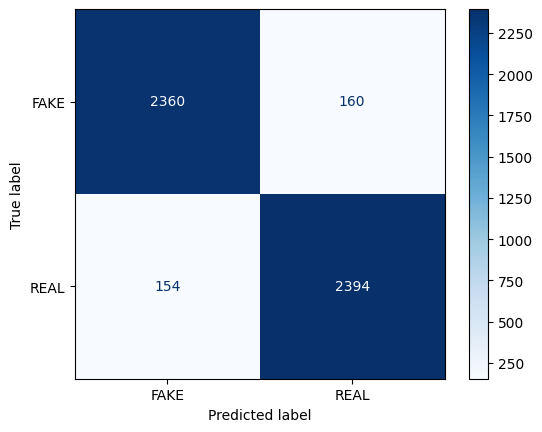

In [10]:
y_pred = fitted_classifier.predict(X_test_features)

metrics.ConfusionMatrixDisplay.from_estimator(fitted_classifier,           # The classifier name
                                                X_train_features,          # The training features
                                                y_train,                   # The training labels
                                                cmap = plt.cm.Blues,       # Colours prettier
                                                labels = ["FAKE", "REAL"])

### Save the trained model and vectorizers

In [ ]:
# save to the folder ```models```
dump(fitted_classifier, "LG_classifier.joblib")
